**Cancer Gene Expression Analysis Using TCGA-BRCA RNA-seq Data**
  
  An End-to-End Bioinformatics Pipeline in Databricks

**Author:** Ume Abiha  
**Dataset:** TCGA Breast Cancer RNA-seq and Clinical Metadata  
**Tools:** Python, Databricks, pandas, NumPy, scikit-learn, Matplotlib  

**Project Goal**

This project analyzes TCGA-BRCA RNA-seq data to compare gene expression patterns between breast tumor and normal tissue samples. The workflow includes data preprocessing, clinical metadata integration, differential gene expression analysis, volcano plot visualization, PCA, K-Means clustering, and Logistic Regression classification.



 **Workflow**

TCGA RNA-seq Data  
↓  
Data Cleaning and Preprocessing  
↓  
Clinical Metadata Integration  
↓  
Sample Annotation: Tumor vs Normal  
↓  
Exploratory Data Analysis  
↓  
Differential Gene Expression Analysis  
↓  
Volcano Plot  
↓  
Principal Component Analysis  
↓  
K-Means Clustering  
↓  
Logistic Regression Classification  
↓  
Final Biological Interpretation


**Data Loading**

In [0]:
# load the dataset
import pandas as pd

# Load gene expression data
expression_df = pd.read_csv("/Workspace/Users/abiha.hhu5@gmail.com/HiSeqV2", sep="\t")

# Load clinical metadata
clinical_df = pd.read_csv("/Workspace/Users/abiha.hhu5@gmail.com/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", sep="\t")

print("Expression dataset:", expression_df.shape)
print("Clinical dataset:", clinical_df.shape)

Expression dataset: (20530, 1219)
Clinical dataset: (1247, 194)


In [0]:
expression_df.head()

,sample,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AC-A5XU-01,TCGA-PE-A5DE-01,TCGA-PE-A5DC-01,TCGA-AR-A0TV-01,TCGA-GM-A3XG-01,TCGA-BH-A18J-01,TCGA-BH-A0W7-01,TCGA-E9-A3QA-01,TCGA-A7-A4SD-01,TCGA-BH-A0HA-01,TCGA-AR-A5QN-01,TCGA-A7-A0CH-11,TCGA-A7-A0CE-01,TCGA-AR-A0U1-01,TCGA-EW-A1OZ-01,TCGA-A2-A0EY-01,TCGA-A8-A09R-01,TCGA-LL-A440-01,TCGA-BH-A8FY-01,TCGA-E2-A1II-01,TCGA-A7-A6VX-01,TCGA-C8-A273-01,TCGA-BH-A1EO-01,TCGA-OL-A5RX-01,TCGA-BH-A0B9-01,TCGA-EW-A1P5-01,TCGA-AO-A03P-01,TCGA-AN-A0AS-01,TCGA-A2-A1G0-01,TCGA-B6-A0I8-01,TCGA-A7-A4SA-01,TCGA-E9-A1RC-11,...,TCGA-E2-A1L6-01,TCGA-BH-A0DG-01,TCGA-A2-A0CP-01,TCGA-BH-A5IZ-01,TCGA-A8-A09W-01,TCGA-E2-A107-01,TCGA-AR-A252-01,TCGA-C8-A12Z-01,TCGA-BH-A202-01,TCGA-AO-A1KT-01,TCGA-D8-A1XW-01,TCGA-D8-A1JU-01,TCGA-E9-A1N5-01,TCGA-A2-A4S1-01,TCGA-E2-A1IG-11,TCGA-E2-A153-01,TCGA-A2-A0YG-01,TCGA-BH-A0B7-01,TCGA-D8-A1X6-01,TCGA-BH-A0BL-01,TCGA-BH-A0DO-01,TCGA-A2-A04Q-01,TCGA-BH-A0B5-11,TCGA-BH-A1FE-06,TCGA-E9-A1NI-01,TCGA-BH-A0HY-01,TCGA-AR-A24T-01,TCGA-E9-A1NF-11,TCGA-AO-A0JA-01,TCGA-D8-A1XZ-01,TCGA-A7-A13E-11,TCGA-C8-A8HP-01,TCGA-E9-A5FL-01,TCGA-AC-A2FB-11,TCGA-E2-A15F-01,TCGA-A2-A3XT-01,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-3C-AALJ-01,TCGA-B6-A0X1-01
0,ARHGEF10L,9.5074,7.4346,9.3216,9.0198,9.6417,9.7665,10.0931,9.1524,9.9398,9.6287,9.6694,10.2287,9.2718,9.5610,11.3338,11.3722,9.8078,10.1081,10.0819,9.5751,9.6685,9.0602,9.5451,9.6014,10.4520,9.8860,9.1870,9.6146,9.7165,9.7915,10.1624,10.0971,9.7215,9.0184,8.7282,10.0161,9.3799,10.7509,9.5920,...,9.7852,8.8111,9.6413,11.6229,7.5288,10.3434,8.8947,8.8813,10.0359,8.6075,10.9642,9.7902,10.1650,10.3455,10.0335,9.9840,8.8155,9.1984,8.8809,9.5235,10.4995,10.0640,9.3597,8.1078,9.7984,9.3400,8.6545,10.4037,8.9976,8.5721,9.6265,10.1826,9.9199,9.9090,10.0334,11.5144,10.5745,9.4048,10.9468,10.3164
1,HIF3A,1.5787,3.6607,2.7224,1.3414,0.5819,0.2738,3.6090,0.4738,2.9378,4.1136,0.4330,5.3420,2.1682,2.6648,2.5048,3.6372,1.9196,5.7390,8.5517,4.1385,4.5824,0.7568,1.3008,0.6560,6.4486,2.5831,5.4853,2.9753,2.1762,2.6206,3.7467,9.5132,0.4654,0.4157,0.0000,6.2594,1.6733,6.0703,9.1444,...,3.8790,3.8834,4.8982,0.5021,0.8787,2.6529,4.4423,0.5770,1.3590,1.6344,2.3822,4.7678,2.1540,2.1386,9.0708,1.6892,0.0000,4.3177,0.5947,6.2779,3.9977,2.2799,8.8463,7.7224,4.2270,0.0000,0.4028,9.4111,0.7707,1.5668,8.1546,2.2159,3.8645,8.1872,0.8836,1.3169,4.0696,7.2537,0.9310,2.4191
2,RNF17,0.0000,0.6245,0.5526,0.0000,0.0000,0.8765,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4324,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.4303,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.9631,0.0000,0.0000,0.0000,0.0000,1.2109,0.0000,0.0000,1.4583,...,6.2440,1.6250,0.0000,0.0000,0.0000,0.0000,0.3744,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6380,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.2703,0.0000,0.0000,0.0000,3.7305,0.0000,0.0000,1.1329,0.4258,0.0000,0.0000,0.0000
3,RNF10,11.3676,11.9181,11.9665,13.1881,12.0036,11.8118,11.3820,11.5004,12.2055,12.1312,11.9378,11.8971,12.3127,11.9861,11.1646,11.5724,12.4059,11.7531,11.9788,11.4626,12.4277,12.0018,11.5879,11.5970,11.5529,12.0487,12.5989,11.3869,12.3921,11.5845,11.7273,12.0289,12.1964,12.2011,11.5278,11.7931,11.4650,11.0259,12.0187,...,12.1443,11.9622,12.0527,11.3430,11.8210,12.4371,11.6447,11.5965,11.4955,11.9798,11.4954,11.7845,11.8549,11.2387,11.8407,11.7244,12.2153,11.4783,12.1456,11.4204,11.8661,11.7065,12.1359,12.2541,12.5475,11.4961,11.6361,11.8686,12.0733,11.9794,11.9869,12.2653,12.4815,11.8263,12.0135,11.5818,11.8663,11.5460,12.2616,12.1570
4,RNF11,11.1292,13.5273,11.4105,11.0911,11.2545,10.8554,10.7663,10.4358,11.2210,10.8013,11.2889,11.3988,11.2739,10.8410,10.8042,11.2059,11.4196,10.9013,11.5315,10.5215,10.5884,10.4395,11.1212,10.7365,10.9343,10.6782,10.8347,11.1685,10.7344,11.7243,11.2360,9.6044,11.3045,11.2983,11.0501,11.8753,10.9028,10.7472,12.2147,...,11.7508,10.9277,11.1117,10.7503

In [0]:
clinical_df.head()

,sampleID,AJCC_Stage_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,CN_Clusters_nature2012,Converted_Stage_nature2012,Days_to_Date_of_Last_Contact_nature2012,Days_to_date_of_Death_nature2012,ER_Status_nature2012,Gender_nature2012,HER2_Final_Status_nature2012,Integrated_Clusters_no_exp__nature2012,Integrated_Clusters_unsup_exp__nature2012,Integrated_Clusters_with_PAM50__nature2012,Metastasis_Coded_nature2012,Metastasis_nature2012,Node_Coded_nature2012,Node_nature2012,OS_Time_nature2012,OS_event_nature2012,PAM50Call_RNAseq,PAM50_mRNA_nature2012,PR_Status_nature2012,RPPA_Clusters_nature2012,SigClust_Intrinsic_mRNA_nature2012,SigClust_Unsupervised_mRNA_nature2012,Survival_Data_Form_nature2012,Tumor_T1_Coded_nature2012,Tumor_nature2012,Vital_Status_nature2012,_INTEGRATION,_PANCAN_CNA_PANCAN_K8,_PANCAN_Cluster_Cluster_PANCAN,_PANCAN_DNAMethyl_BRCA,_PANCAN_DNAMethyl_PANCAN,_PANCAN_RPPA_PANCAN_K8,_PANCAN_UNC_RNAseq_PANCAN_K16,_PANCAN_miRNA_PANCAN,_PANCAN_mirna_BRCA,_PANCAN_mutation_PANCAN,_PATIENT,...,positive_finding_estrogen_receptor_other_measurement_scale_text,postoperative_rx_tx,primary_lymph_node_presentation_assessment,progesterone_receptor_level_cell_percent_category,project_code,radiation_therapy,sample_type,sample_type_id,surgical_procedure_purpose_other_text,system_version,targeted_molecular_therapy,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,tissue_source_site,tumor_tissue_site,vial_number,vital_status,year_of_initial_pathologic_diagnosis,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_exon,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_PANCAN,_GENOMIC_ID_TCGA_BRCA_RPPA_RBN,_GENOMIC_ID_TCGA_BRCA_mutation,_GENOMIC_ID_TCGA_BRCA_PDMRNAseq,_GENOMIC_ID_TCGA_BRCA_hMethyl450,_GENOMIC_ID_TCGA_BRCA_RPPA,_GENOMIC_ID_TCGA_BRCA_PDMRNAseqCNV,_GENOMIC_ID_TCGA_BRCA_mutation_curated_wustl_gene,_GENOMIC_ID_TCGA_BRCA_hMethyl27,_GENOMIC_ID_TCGA_BRCA_PDMarrayCNV,_GENOMIC_ID_TCGA_BRCA_miRNA_HiSeq,_GENOMIC_ID_TCGA_BRCA_mutation_wustl_gene,_GENOMIC_ID_TCGA_BRCA_miRNA_GA,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_percentile,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_GA_gene,_GENOMIC_ID_TCGA_BRCA_gistic2thd,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_HiSeq_gene,_GENOMIC_ID_TCGA_BRCA_G4502A_07_3,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2,_GENOMIC_ID_TCGA_BRCA_gistic2,_GENOMIC_ID_TCGA_BRCA_PDMarray
0,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AAAU,...,NaN,NO,YES,50-59%,NaN,NO,Primary Tumor,1,NaN,6th,NaN,NO,YES,3C,Breast,A,LIVING,2004.0,6ef883fc-81f3-4089-95e0-86904ffc0d38,6ef883fc-81f3-4089-95e0-86904ffc0d38,NaN,NaN,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01A-11D-A41Q-05,NaN,TCGA-3C-AAAU-01,NaN,NaN,NaN,TCGA-3C-AAAU-01,NaN,NaN,6ef883fc-81f3-4089-95e0-86904ffc0d38,NaN,TCGA-3C-AAAU-01A-11D-A41E-01,TCGA-3C-AAAU-01,NaN,6ef883fc-81f3-4089-95e0-86904ffc0d38,TCGA-3C-AAAU-01A-11D-A41E-01,NaN
1,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALI,...,NaN,YES,YES,<10%,NaN,YES,Primary Tumor,1,NaN,6th,NaN,NO,YES,3C,Breast,A,LIVING,2003.0,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,NaN,NaN,TCGA-3C-AALI-01,TCGA-3C-AALI-01A-11D-A41Q-05,1B37DE89-DEB6-4049-A2D4-450A4A1DE5D3,TCGA-3C-AALI-01,NaN,NaN,NaN,TCGA-3C-AALI-01,NaN,NaN,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,NaN,TCGA-3C-AALI-01A-11D-A41E-01,TCGA-3C-AALI-01,NaN,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,TCGA-3C-AALI-01A-11D-A41E-01,NaN
2,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALJ,...,NaN,NO,YES,30-39%,NaN,NO,Primary Tumor,1,NaN,7th,NaN,NO,YES,3C,Breast,NaN,LIVING,2011.0,c924c2a8-ab41-4499-bb30-79705cc17d45,c924c2a8-ab41-4499-bb30-79705cc17d45,NaN,NaN,TCGA-3C-AALJ-01,TCGA-3C-AALJ

In [0]:
#identify the patient IDs
expression_df.columns[:5]


Index(['sample', 'TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01',
       'TCGA-BH-A0BT-01'],
      dtype='object')

In [0]:
clinical_df.columns[0]

'sampleID'

In [0]:
print(expression_df.shape)
print(clinical_df.shape)
print(expression_df.head())
print(clinical_df.head())
print(expression_df.columns[:5])
print(clinical_df.columns[:10])


(20530, 1219)
(1247, 194)
      sample  TCGA-AR-A5QQ-01  ...  TCGA-3C-AALJ-01  TCGA-B6-A0X1-01
0  ARHGEF10L           9.5074  ...          10.9468          10.3164
1      HIF3A           1.5787  ...           0.9310           2.4191
2      RNF17           0.0000  ...           0.0000           0.0000
3      RNF10          11.3676  ...          12.2616          12.1570
4      RNF11          11.1292  ...          10.7842          11.2420

[5 rows x 1219 columns]
          sampleID  ... _GENOMIC_ID_TCGA_BRCA_PDMarray
0  TCGA-3C-AAAU-01  ...                            NaN
1  TCGA-3C-AALI-01  ...                            NaN
2  TCGA-3C-AALJ-01  ...                            NaN
3  TCGA-3C-AALK-01  ...                            NaN
4  TCGA-4H-AAAK-01  ...                            NaN

[5 rows x 194 columns]
Index(['sample', 'TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01',
       'TCGA-BH-A0BT-01'],
      dtype='object')
Index(['sampleID', 'AJCC_Stage_nature2012',
       'Age_at

In [0]:
#Check for missing values
print("Missing values in expression data:")
print(expression_df.isnull().sum().sum())

print("\nMissing values in clinical data:")
print(clinical_df.isnull().sum().sum())

Missing values in expression data:
0

Missing values in clinical data:
116445


In [0]:
expression_samples = set(expression_df.columns[1:])
clinical_samples = set(clinical_df["sampleID"])

common_samples = expression_samples.intersection(clinical_samples)

print("Expression samples:", len(expression_samples))
print("Clinical samples:", len(clinical_samples))
print("Common samples:", len(common_samples))

Expression samples: 1218
Clinical samples: 1247
Common samples: 1218


**Data Cleaning & Preprocessing**

In [0]:
# Transpose expression matrix
expression_t = expression_df.set_index("sample").T

# Convert patient IDs from index to a column
expression_t.reset_index(inplace=True)

# Rename the patient ID column
expression_t.rename(columns={"index": "sampleID"}, inplace=True)

# Check the new shape
print(expression_t.shape)

# View first few rows
expression_t.head()

(1218, 20531)


sample,sampleID,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,C16orf13,C16orf11,FGFR1OP2,TSKS,ATRX,PMM2,LOC100272146,ASS1,NCBP1,ZNF709,ZNF708,RBM14,NCBP2,DISC1,CAMK1,RPL37,SPR,ZNF700,ZNF707,CAMK4,ZNF704,LOC339240,GOLGA6B,RNF115,RNF112,ZC3H14,SPN,HMGCLL1,NACAP1,...,ACAP1,ACAP2,ACAP3,LUZP4,OR10J5,LUZP6,C1orf198,CFL2,CFL1,OR10J3,C8orf83,C1orf192,PLAA,C8orf80,C8orf86,C8orf85,C8orf84,NFIC,NFIB,H1FOO,NFIX,PLEKHG6,PLEKHG7,PLEKHG4,PLEKHG5,SLC7A14,SELE,SLC7A10,PLA2G2C,METTL11A,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,9.7940,0.5819,8.8440,1.9930,9.4263,10.3735,3.0792,9.5279,10.3001,5.2763,6.3037,10.3336,10.8729,6.0783,8.6979,14.0584,9.0213,7.5794,7.8611,4.3130,5.0784,0.0000,0.5819,8.4274,1.9930,10.4075,8.5624,0.9953,7.6453,...,9.0047,9.6693,10.3543,0.0,0.0,12.1802,9.6091,9.2026,15.0181,0.0,8.5775,1.8007,9.2291,5.2763,0.0000,4.6057,6.6981,8.5123,8.0940,0.0000,9.0487,6.2387,1.8007,4.8736,10.2818,0.0000,8.4885,0.5914,0.0,10.1768,0.5819,0.0000,5.3307,0.5819,9.1928,13.8808,7.3830,11.4289,7.8456,10.7384
1,TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,7.6658,0.0000,9.0535,0.0000,11.8369,10.3916,4.6343,10.6646,10.9484,7.1969,8.8492,10.1715,10.6518,7.6168,5.4037,12.7034,7.6307,8.7690,5.4792,1.5341,9.5254,0.0000,2.1767,9.6088,1.9926,10.5945,4.7109,4.5367,7.0454,...,2.0876,10.9801,7.3628,0.0,0.0,12.6814,11.5884,8.4838,13.4429,0.0,10.7533,4.6025,12.2588,1.5341,0.6245,7.5265,10.6474,9.7366,9.7795,0.0000,8.2789,8.4772,3.6913,5.8482,5.2924,0.0000,2.9582,0.6245,0.0,6.7493,1.0589,0.0000,3.1017,3.7793,9.8340,10.7066,7.2467,9.1673,0.0000,10.1225
2,TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,10.0717,0.0000,8.4629,1.5193,10.6263,10.3312,4.2275,11.9019,9.9627,5.8563,6.4329,9.9259,10.8630,6.9291,7.8807,14.1788,9.9847,7.8345,6.9673,4.5484,7.4363,0.0000,0.0000,9.4893,2.6166,10.2826,7.5909,3.3025,7.1347,...,7.1957,9.5888,9.3487,0.0,0.0,11.5931,11.4454,8.0682,14.2582,0.0,9.6062,8.0197,9.9538,1.7370,0.0000,8.6388,7.5157,10.5711,11.8987,0.9511,10.8036,8.0301,3.2326,7.0860,8.0632,0.9511,6.5088,3.4981,0.0,8.9442,0.0000,2.7224,4.2976,0.0000,9.2304,12.9973,8.3374,11.3400,8.3765,9.9367
3,TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,10.7406,0.0000,8.4495,1.1046,10.2377,11.4924,5.6240,9.6035,9.4741,7.0460,6.8199,10.1629,11.3431,5.7527,7.5985,13.2402,9.4702,8.6948,8.7317,3.6879,6.7801,0.0000,0.8213,9.1924,2.7553,11.1037,7.0873,1.7229,6.8962,...,6.7902,9.4764,8.2641,0.0,0.0,11.6083,11.2472,7.6104,14.8888,0.0,10.1134,6.5807,10.0454,1.3414,2.8350,7.2119,5.9713,8.5533,8.4126,0.0000,11.2364,8.3308,2.9106,5.5668,7.8330,0.4683,7.4615,1.1276,0.0,8.0172,0.0000,2.9823,4.3067,0.0000,8.7816,12.3298,7.7036,11.3025,7.0585,9.3784
4,TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,9.6876,0.0000,8.3679,2.1627,10.9590,10.6422,3.6918,11.5567,9.8401,7.2575,7.0514,10.2424,11.2374,6.3831,7.8067,12.9157,11.9365,9.7867,8.3916,2.4518,6.9155,0.5819,0.5819,9.3193,0.5819,9.4735,6.6842,0.5819,7.0296,...,5.4987,9.7564,9.0324,0.0,0.0,11.6446,10.9973,6.8549,14.0914,0.0,9.4419,3.9912,10.6273,1.8007,0.0000,6.8672,2.4518,10.4684,8.4905,0.0000,11.5103,8.0269,0.0000,8.9991,7.8045,0.0000,5.8237,1.8007,0.0,8.3286,1.3163,0.5819,3.5764,0.0000,9.3024,11.3338,7.7186,10.6898,7.0992,11.1740


In [0]:
expression_t.columns[:5]

Index(['sampleID', 'ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10'], dtype='object', name='sample')

**Clinical Metadata Integration**

In [0]:

# merging molecular data with clinical data.
merged_df = clinical_df.merge(
    expression_t,
    on="sampleID",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(1218, 20724)


,sampleID,AJCC_Stage_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,CN_Clusters_nature2012,Converted_Stage_nature2012,Days_to_Date_of_Last_Contact_nature2012,Days_to_date_of_Death_nature2012,ER_Status_nature2012,Gender_nature2012,HER2_Final_Status_nature2012,Integrated_Clusters_no_exp__nature2012,Integrated_Clusters_unsup_exp__nature2012,Integrated_Clusters_with_PAM50__nature2012,Metastasis_Coded_nature2012,Metastasis_nature2012,Node_Coded_nature2012,Node_nature2012,OS_Time_nature2012,OS_event_nature2012,PAM50Call_RNAseq,PAM50_mRNA_nature2012,PR_Status_nature2012,RPPA_Clusters_nature2012,SigClust_Intrinsic_mRNA_nature2012,SigClust_Unsupervised_mRNA_nature2012,Survival_Data_Form_nature2012,Tumor_T1_Coded_nature2012,Tumor_nature2012,Vital_Status_nature2012,_INTEGRATION,_PANCAN_CNA_PANCAN_K8,_PANCAN_Cluster_Cluster_PANCAN,_PANCAN_DNAMethyl_BRCA,_PANCAN_DNAMethyl_PANCAN,_PANCAN_RPPA_PANCAN_K8,_PANCAN_UNC_RNAseq_PANCAN_K16,_PANCAN_miRNA_PANCAN,_PANCAN_mirna_BRCA,_PANCAN_mutation_PANCAN,_PATIENT,...,ACAP1,ACAP2,ACAP3,LUZP4,OR10J5,LUZP6,C1orf198,CFL2,CFL1,OR10J3,C8orf83,C1orf192,PLAA,C8orf80,C8orf86,C8orf85,C8orf84,NFIC,NFIB,H1FOO,NFIX,PLEKHG6,PLEKHG7,PLEKHG4,PLEKHG5,SLC7A14,SELE,SLC7A10,PLA2G2C,METTL11A,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AAAU,...,5.1057,10.4170,11.0919,0.4273,0.0,12.0063,10.2042,7.5531,13.3918,0.0,9.8847,5.9054,9.7404,2.7037,2.3606,12.2973,5.3075,11.1381,7.4142,0.0,12.4178,8.7839,1.2501,8.7589,7.6000,0.0,4.8191,0.7594,0.0000,8.2385,0.0000,2.1527,3.7074,0.0000,8.9560,11.4006,7.8250,12.1997,5.6018,9.7282
1,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALI,...,8.3130,10.1252,10.1803,0.0000,0.0,11.3743,11.2768,7.0685,14.6126,0.0,9.4607,4.1138,9.0493,4.6396,1.0618,6.6897,5.2676,9.2242,11.0613,0.0,9.0823,9.4752,7.2024,8.9835,8.1263,0.0,6.5544,3.5174,0.0000,9.4181,1.0618,1.6668,4.9499,3.2780,9.3888,12.1666,8.1093,10.7031,5.5942,10.0766
2,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALJ,...,8.2811,9.4771,10.9442,0.0000,0.0,11.3545,10.7760,7.7357,14.3687,0.0,10.0223,3.5704,9.8573,4.3247,5.9900,7.9466,5.9482,9.6053,9.5609,0.0,8.8189,9.1649,1.4922,8.2513,8.3428,0.0,4.2579,3.7848,0.0000,9.6699,0.0000,0.9310,4.2579,1.4922,9.3284,12.5534,8.7597,12.0469,5.6941,10.1682
3,TCGA-3C-AALK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-3C-AALK,...,7.2441,9.5377,10.0981,0.0000,0.0,11.3045,11.3224,7.7475,14.6880,0.0,9.6820,5.8397,9.5329,3.2133,2.1077,8.1912,9.5835,9.9088,11.1114,0.0,10.7099,8.2472,2.4728,7.4217,9.2449,0.0,8.8656,0.8796,0.0000,8.9109,1.1643,1.4087,4.2634,0.0000,9.3354,13.0257,7.9614,11.3719,8.6253,10.2333
4,TCGA-4H-AAAK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-4H-AAAK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TCGA-4H-AAAK,...,6.9340,10.0101,9.6290,0.0000,0.0,11.4332,10.6344,7.6753,13.9866,0.0,10.0524,4.3923,9.7626,2.2720,0.0000,6.9638,9.1898,9.6045,10.9942,0.0,11.6683,7.1569,1.8291,9.5958,8.1523,0.0,5.1657,1.1896,0.5115,9.1920,1.4341,0.8884,3.9904,0.0000,9.0038,13.1156,7.6902,10.8298,5.7256,10.0402


In [0]:
merged_df[
    [
        "sampleID",
        "Gender_nature2012",
        "Age_at_Initial_Pathologic_Diagnosis_nature2012",
        "ER_Status_nature2012",
        "HER2_Final_Status_nature2012"
    ]
].head(20)

,sampleID,Gender_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,ER_Status_nature2012,HER2_Final_Status_nature2012
0,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN
1,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN
2,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN
3,TCGA-3C-AALK-01,NaN,NaN,NaN,NaN
4,TCGA-4H-AAAK-01,NaN,NaN,NaN,NaN
5,TCGA-5L-AAT0-01,NaN,NaN,NaN,NaN
6,TCGA-5L-AAT1-01,NaN,NaN,NaN,NaN
7,TCGA-5T-A9QA-01,NaN,NaN,NaN,NaN
8,TCGA-A1-A0SB-01,FEMALE,70.0,Positive,Negative
9,TCGA-A1-A0SD-01,FEMALE,59.0,Positive,Negative


In [0]:
# Number of missing values per column
clinical_missing = merged_df.isnull().sum().sort_values(ascending=False)
clinical_missing.head(20)


mtsttc_brst_crcnm_hr2_rbb_ps_fndng_flrscnc_n_st_hybrdztn_clcltn     1217
hr2_n_nd_cntrmr_17_cpy_nmbr_mtsttc_brst_crcnm_nlyss_npt_ttl_nmbr    1216
days_to_additional_surgery_locoregional_procedure                   1216
metastatic_breast_carcinoma_pos_finding_hr2_rbb2_thr_msr_scl_txt    1216
days_to_last_known_alive                                            1216
metastatic_breast_carcinoma_her2_erbb_method_calculatin_mthd_txt    1215
mtsttc_brst_crcnm_flrscnc_n_st_hybrdztn_dgnstc_prc_cntrmr_17_sgn    1215
her2_neu_metastatic_breast_carcinoma_copy_analysis_inpt_ttl_nmbr    1215
pos_finding_metastatic_brst_crcnm_strgn_rcptr_thr_msrmnt_scl_txt    1214
metastatic_breast_carcinm_ps_fndng_prgstrn_rcptr_thr_msr_scl_txt    1214
metastatic_breast_carcinoma_estrogen_receptor_detection_mthd_txt    1214
metastatic_breast_carcinoma_progesterone_receptor_dtctn_mthd_txt    1214
her2_and_centromere_17_positive_finding_other_measuremnt_scl_txt    1213
disease_code                                       

In [0]:
merged_df[
    [
        "Gender_nature2012",
        "Age_at_Initial_Pathologic_Diagnosis_nature2012",
        "ER_Status_nature2012",
        "HER2_Final_Status_nature2012",
        "PR_Status_nature2012",
        "AJCC_Stage_nature2012"
    ]
].describe(include="all")

,Gender_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,ER_Status_nature2012,HER2_Final_Status_nature2012,PR_Status_nature2012,AJCC_Stage_nature2012
count,933,933.000000,782,776,781,779
unique,2,NaN,3,3,3,12
top,FEMALE,NaN,Positive,Negative,Positive,Stage IIA
freq,924,NaN,601,652,522,249
mean,NaN,57.815648,NaN,NaN,NaN,NaN
std,NaN,13.398173,NaN,NaN,NaN,NaN
min,NaN,26.000000,NaN,NaN,NaN,NaN
25%,NaN,48.000000,NaN,NaN,NaN,NaN
50%,NaN,58.000000,NaN,NaN,NaN,NaN
75%,NaN,67.000000,NaN,NaN,NaN,NaN


In [0]:
# Get the last two digits of every sample ID
sample_types = expression_t["sampleID"].str[-2:].value_counts()
print(sample_types)

sampleID
01    1097
11     114
06       7
Name: count, dtype: int64


**Sample Annotation**

In [0]:
# Extract the last two digits from each sample ID
merged_df["Sample_Code"] = merged_df["sampleID"].str[-2:]

# Convert codes into meaningful labels
merged_df["Sample_Type"] = merged_df["Sample_Code"].map({
    "01": "Tumor",
    "11": "Normal",
    "06": "Metastatic"
})

# Check the result
merged_df[["sampleID", "Sample_Code", "Sample_Type"]].head(10)

,sampleID,Sample_Code,Sample_Type
0,TCGA-3C-AAAU-01,01,Tumor
1,TCGA-3C-AALI-01,01,Tumor
2,TCGA-3C-AALJ-01,01,Tumor
3,TCGA-3C-AALK-01,01,Tumor
4,TCGA-4H-AAAK-01,01,Tumor
5,TCGA-5L-AAT0-01,01,Tumor
6,TCGA-5L-AAT1-01,01,Tumor
7,TCGA-5T-A9QA-01,01,Tumor
8,TCGA-A1-A0SB-01,01,Tumor
9,TCGA-A1-A0SD-01,01,Tumor


In [0]:
merged_df["Sample_Type"].value_counts()

Sample_Type
Tumor         1097
Normal         114
Metastatic       7
Name: count, dtype: int64

In [0]:
analysis_df = merged_df[
    merged_df["Sample_Type"].isin(["Tumor", "Normal"])
].copy()

print(analysis_df["Sample_Type"].value_counts())
print(analysis_df.shape)

Sample_Type
Tumor     1097
Normal     114
Name: count, dtype: int64
(1211, 20726)


**Exploratory Data Analysis (EDA)**

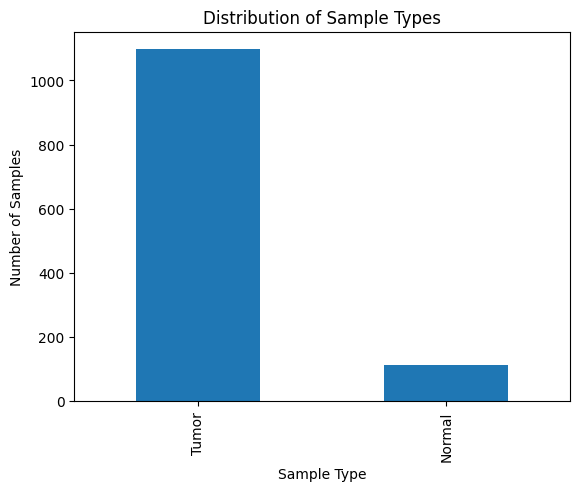

In [0]:
#class Distribution

import matplotlib.pyplot as plt

analysis_df["Sample_Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Sample Types")
plt.xlabel("Sample Type")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation**

The dataset is imbalanced, with tumor samples representing approximately 91% of all samples and normal tissue representing approximately 9%.

This is expected because TCGA was primarily designed to study cancer, so many more tumor tissues were collected than normal tissues.

In [0]:
#Basic Dataset Statistics
print("Rows (Patients):", analysis_df.shape[0])
print("Columns:", analysis_df.shape[1])

print("\nTumor samples:")
print((analysis_df["Sample_Type"] == "Tumor").sum())

print("\nNormal samples:")
print((analysis_df["Sample_Type"] == "Normal").sum())

Rows (Patients): 1211
Columns: 20726

Tumor samples:
1097

Normal samples:
114


In [0]:
#Choose One Gene to Explore
analysis_df["HIF3A"].describe()

count    1211.000000
mean        3.348863
std         2.346868
min         0.000000
25%         1.583300
50%         2.779500
75%         4.664950
max        11.156800
Name: HIF3A, dtype: float64

**Single-Gene Analysis: HIF3A**



/home/spark-253a3f8f-bf81-4933-9925-8d/.ipykernel/326/command-5741022104287063-1396584402:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tumor, normal], labels=["Tumor", "Normal"])


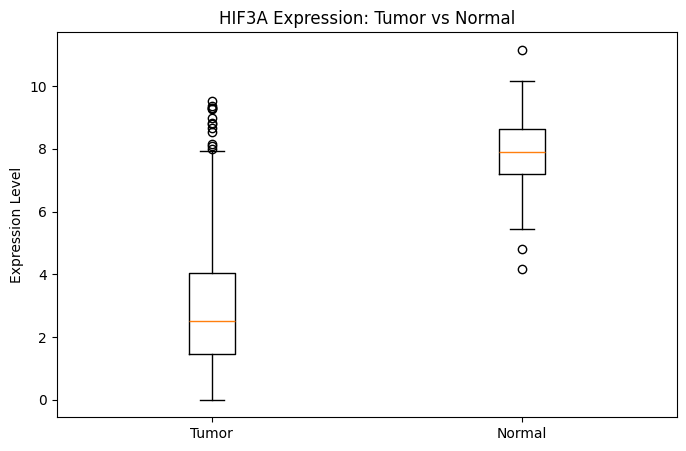

In [0]:
#Compare Tumor vs. Normal Expression

import matplotlib.pyplot as plt

tumor = analysis_df[analysis_df["Sample_Type"] == "Tumor"]["HIF3A"]
normal = analysis_df[analysis_df["Sample_Type"] == "Normal"]["HIF3A"]

plt.figure(figsize=(8,5))
plt.boxplot([tumor, normal], labels=["Tumor", "Normal"])

plt.title("HIF3A Expression: Tumor vs Normal")
plt.ylabel("Expression Level")

plt.show()

**Interpretation**

These findings suggest that HIF3A is **downregulated** in breast tumor tissue compared with normal breast tissue within the TCGA-BRCA dataset. The visible difference between the two distributions indicates that HIF3A may be associated with biological processes altered during breast cancer development.

At this stage, the observation is based solely on visual inspection. A formal statistical test is required to determine whether the observed difference is statistically significant rather than due to random variation.

**Statistical Comparison of Gene Expression**

In [0]:
from scipy.stats import mannwhitneyu

tumor = analysis_df[analysis_df["Sample_Type"] == "Tumor"]["HIF3A"]
normal = analysis_df[analysis_df["Sample_Type"] == "Normal"]["HIF3A"]

statistic, p_value = mannwhitneyu(
    tumor,
    normal,
    alternative="two-sided"
)

print("U statistic:", statistic)
print("P-value:", p_value)



U statistic: 2930.5
P-value: 4.0757169215393505e-63


**Null hypothesis (H₀)**

HIF3A expression is the same in tumor and normal tissue.

**Alternative hypothesis (H₁)**

HIF3A expression is different between tumor and normal tissue.

In [0]:
#Interpret the p-value
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in HIF3A expression.")
else:
    print("Fail to reject the null hypothesis.")
    print("No statistically significant difference detected.")

Reject the null hypothesis.
There is a statistically significant difference in HIF3A expression.


**Interpretation:**

The analysis demonstrates that the expression of HIF3A differs significantly between primary breast tumor tissue and normal breast tissue in the TCGA-BRCA cohort.

This finding is consistent with the previous boxplot, which showed noticeably lower HIF3A expression in tumor samples compared with normal tissue. The statistical test confirms that this observed difference is highly **unlikely** to have occurred by random chance.

**Differential Gene Expression (Genome-wide)**

In [0]:
#Choose the gene columns

gene_columns = expression_t.columns[1:]

print("Number of genes:", len(gene_columns))
print(gene_columns[:10])

Number of genes: 20530
Index(['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1',
       'REM1', 'MTVR2', 'RTN4RL2'],
      dtype='object', name='sample')


In [0]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

results = []

# Analyze all genes
test_genes = gene_columns

for gene in test_genes:

    tumor = analysis_df.loc[
        analysis_df["Sample_Type"] == "Tumor", gene
    ]

    normal = analysis_df.loc[
        analysis_df["Sample_Type"] == "Normal", gene
    ]

    # Mean expression
    tumor_mean = tumor.mean()
    normal_mean = normal.mean()

    # Statistical test
    stat, p_value = mannwhitneyu(
        tumor,
        normal,
        alternative="two-sided"
    )

    # Log2 Fold Change (THIS IS WHERE IT GOES)
    log2fc = np.log2((tumor_mean + 1) / (normal_mean + 1))

    # Save results
    results.append({
        "Gene": gene,
        "Tumor_Mean": tumor_mean,
        "Normal_Mean": normal_mean,
        "Log2FC": log2fc,
        "P_Value": p_value
    })

# Create DataFrame
dge_results = pd.DataFrame(results)

# Calculate -log10(P-value)
dge_results["NegLog10_P"] = -np.log10(dge_results["P_Value"])

# Sort genes
dge_results = dge_results.sort_values("P_Value")

dge_results.head(10)

,Gene,Tumor_Mean,Normal_Mean,Log2FC,P_Value,NegLog10_P
16311,KRTAP13-4,0.015289,0.418334,-0.482306,6.218631e-73,72.206305
11818,AADACL2,0.158196,1.423585,-1.065263,2.309154e-70,69.636547
15179,CPA1,0.745907,4.601289,-1.681782,7.199003e-69,68.142728
5522,LOC572558,0.613613,3.707292,-1.544603,1.631806e-68,67.787331
8085,CA4,1.500376,8.104417,-1.864422,2.377527e-68,67.623875
4367,FIGF,3.033205,9.188756,-1.336979,5.836389e-68,67.233856
2783,SDPR,6.672736,11.370902,-0.689138,1.023778e-67,66.989794
12960,MMP11,12.315019,6.493440,0.829354,1.123838e-67,66.949296
10803,CD300LG,3.833923,10.300038,-1.225061,1.150940e-67,66.938947
18301,ADAMTS5,7.636122,11.178399,-0.495869,2.332673e-67,66.632146


In [0]:
p_threshold = 0.05
fc_threshold = 1

dge_results["Significance"] = "Not Significant"

dge_results.loc[
    (dge_results["P_Value"] < p_threshold) &
    (dge_results["Log2FC"] > fc_threshold),
    "Significance"
] = "Upregulated"

dge_results.loc[
    (dge_results["P_Value"] < p_threshold) &
    (dge_results["Log2FC"] < -fc_threshold),
    "Significance"
] = "Downregulated"

dge_results["Significance"].value_counts()

Significance
Not Significant    20253
Downregulated        190
Upregulated           87
Name: count, dtype: int64

**Volcano Plot**

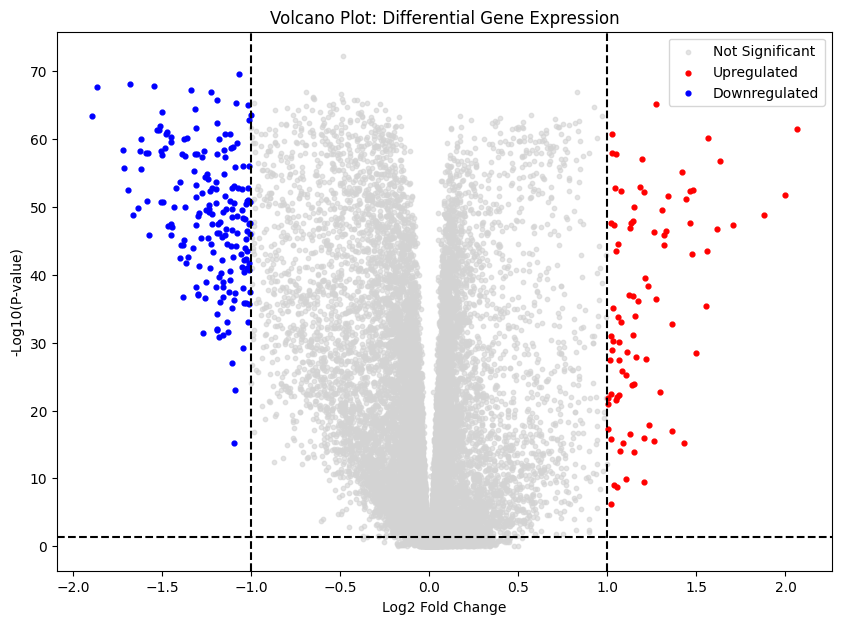

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

# Not Significant
plt.scatter(
    dge_results[dge_results["Significance"]=="Not Significant"]["Log2FC"],
    dge_results[dge_results["Significance"]=="Not Significant"]["NegLog10_P"],
    color="lightgray",
    s=10,
    alpha=0.6,
    label="Not Significant"
)

# Upregulated
plt.scatter(
    dge_results[dge_results["Significance"]=="Upregulated"]["Log2FC"],
    dge_results[dge_results["Significance"]=="Upregulated"]["NegLog10_P"],
    color="red",
    s=12,
    label="Upregulated"
)

# Downregulated
plt.scatter(
    dge_results[dge_results["Significance"]=="Downregulated"]["Log2FC"],
    dge_results[dge_results["Significance"]=="Downregulated"]["NegLog10_P"],
    color="blue",
    s=12,
    label="Downregulated"
)

# Threshold lines
plt.axvline(x=1, color="black", linestyle="--")
plt.axvline(x=-1, color="black", linestyle="--")
plt.axhline(y=-np.log10(0.05), color="black", linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(P-value)")
plt.title("Volcano Plot: Differential Gene Expression")

plt.legend()
plt.savefig("volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Principal Component Analysis**

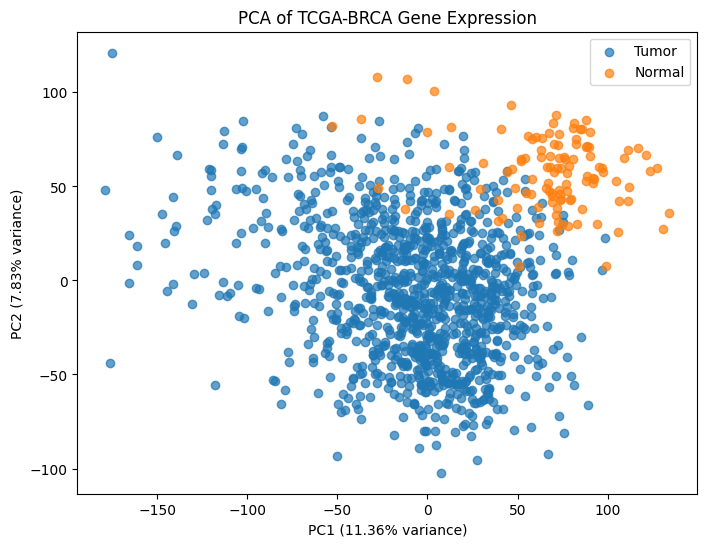

In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use only gene expression columns
X = analysis_df[gene_columns]

# Scale gene expression values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["Sample_Type"] = analysis_df["Sample_Type"].values

# Plot PCA
plt.figure(figsize=(8,6))

for sample_type in pca_df["Sample_Type"].unique():
    subset = pca_df[pca_df["Sample_Type"] == sample_type]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=sample_type,
        alpha=0.7
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.title("PCA of TCGA-BRCA Gene Expression")
plt.legend()
plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**K-Means Clustering**

In [0]:
#Run K-Means

from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit model
pca_df["Cluster"] = kmeans.fit_predict(
    pca_df[["PC1", "PC2"]]
)

pca_df.head()

,PC1,PC2,Sample_Type,Cluster
0,-16.779892,-40.285285,Tumor,0
1,-59.642926,5.175689,Tumor,1
2,-62.732232,6.826142,Tumor,1
3,-29.225961,11.928456,Tumor,1
4,-11.224112,10.683943,Tumor,1


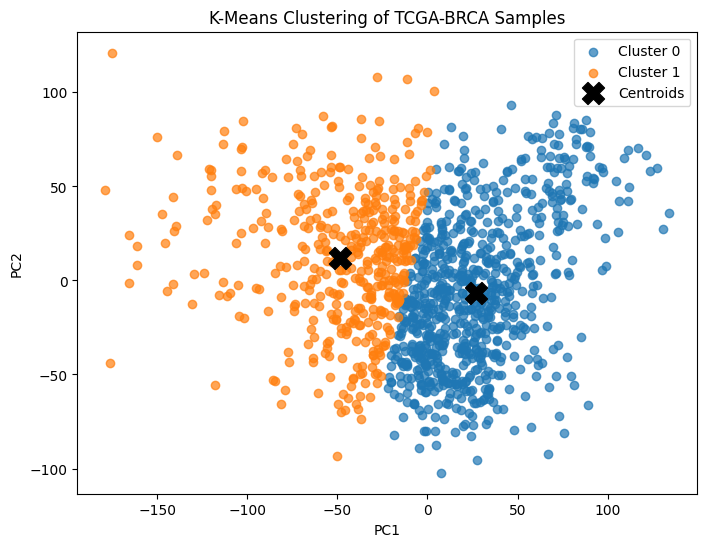

In [0]:
#Visualize the clusters

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering of TCGA-BRCA Samples")
plt.legend()
plt.savefig("kmeans_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
pd.crosstab(
    pca_df["Cluster"],
    pca_df["Sample_Type"]
)

Sample_Type,Normal,Tumor
Cluster,,
0,106,674
1,8,423


**Logistic Regression Classification**

In [0]:
from sklearn.model_selection import train_test_split

# Features
X = pca_df[["PC1", "PC2"]]

# Labels
y = pca_df["Sample_Type"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 968
Testing samples: 243


In [0]:
#Train the model

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [0]:
#Make predictions
y_pred = model.predict(X_test)
print(y_pred[:10])

['Tumor' 'Tumor' 'Tumor' 'Tumor' 'Tumor' 'Tumor' 'Tumor' 'Tumor' 'Tumor'
 'Tumor']


In [0]:
#Evaluate the model
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9835390946502057

Confusion Matrix:
[[ 21   2]
 [  2 218]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91        23
       Tumor       0.99      0.99      0.99       220

    accuracy                           0.98       243
   macro avg       0.95      0.95      0.95       243
weighted avg       0.98      0.98      0.98       243



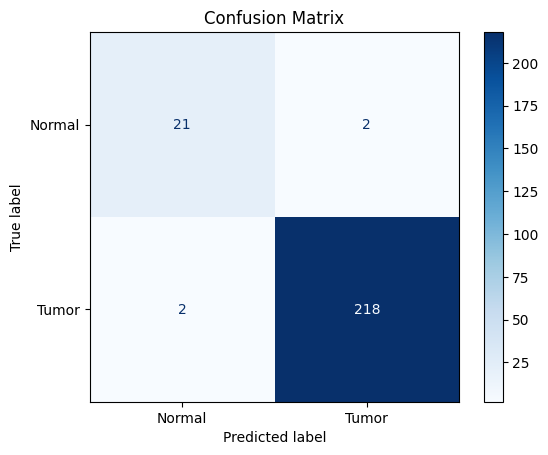

In [0]:
#Visualize the Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
# Confusion Matrix
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation**

The Logistic Regression model achieved excellent classification performance despite using only the first two principal components as input features.

The confusion matrix demonstrates that the model was able to distinguish tumor and normal breast tissue with high accuracy, indicating that the principal components successfully captured biologically meaningful variation in gene expression.

The small number of misclassified samples suggests that the transcriptional differences between tumor and normal tissue are sufficiently strong to support reliable prediction using a simple linear classifier.

Overall, the supervised learning analysis complements the previous unsupervised analyses (PCA and K-Means) by quantitatively demonstrating that genome-wide RNA-seq expression profiles can accurately discriminate between cancerous and normal breast tissue.

**Final Conclusion**

This project presented an end-to-end bioinformatics workflow for the analysis of breast cancer RNA-seq data obtained from the TCGA-BRCA cohort.

The analysis began with data preprocessing, including cleaning gene expression and clinical datasets, merging patient information, and annotating samples as tumor or normal tissue. Exploratory data analysis provided an initial understanding of the dataset and confirmed the presence of both biological groups.

A preliminary investigation of the HIF3A gene demonstrated significantly lower expression in tumor tissue compared with normal tissue. This observation was confirmed statistically using the Mann–Whitney U test.

The analysis was then expanded to a genome-wide differential gene expression study across all 20,530 genes. Log₂ Fold Change values quantified the magnitude and direction of expression changes, while a volcano plot highlighted genes showing both statistically significant and biologically meaningful differences between tumor and normal tissue.

Principal Component Analysis demonstrated that tumor and normal samples exhibit distinct global gene expression profiles, although some overlap remained due to the biological heterogeneity of breast cancer.

Unsupervised learning using K-Means clustering identified meaningful structure within the data, revealing that samples naturally grouped according to similarities in their transcriptomic profiles.

Finally, a Logistic Regression classifier achieved an accuracy of 98.35%, demonstrating that gene expression patterns provide strong predictive power for distinguishing tumor from normal breast tissue.

Overall, this project illustrates a complete bioinformatics pipeline integrating data preprocessing, statistical analysis, visualization, unsupervised learning, and supervised machine learning. The workflow demonstrates practical experience with Python, pandas, NumPy, scikit-learn, and statistical methods commonly applied in cancer genomics and bioinformatics research.


**Export Results**

In [0]:
# Save differential gene expression results
dge_results.to_csv("dge_results.csv", index=False)

# Save PCA results
pca_df.to_csv("pca_results.csv", index=False)

print("Files exported successfully.")

Files exported successfully.
